# Imports

In [50]:
from data_explorer_class import DataExplorer 
from data_cleaning_class import DataCleaner
import pandas as pd
import numpy as np 
import lightgbm as lgb
import itertools
from sklearn.model_selection import GroupKFold , GridSearchCV  , GroupShuffleSplit
from sklearn.metrics import mean_squared_error
pd.set_option('display.max_rows', None)
import os
import time
from catboost import CatBoostRegressor

script_dir = os.getcwd()
train_path = os.path.join(script_dir , "train.csv")
test_path  = os.path.join(script_dir , "test.csv")
solution_path = os.path.join(script_dir,"solution.csv")


train_df  = pd.read_csv(train_path)
test_df   = pd.read_csv(test_path)
solution_path = pd.read_csv(solution_path)

# Preprocessing 

## Data Exploring ~ before cleaning

-----------------
DataSet Shape is (43584, 75)
-----------------
-----------------


=== STATISTICS ===
                age  jersey_number     height_cm     weight_kg  \
count  43584.000000   43584.000000  43584.000000  43584.000000   
mean      26.414648      13.472215    181.582760     75.814244   
std        4.036415       7.482398      6.332509      3.910184   
min       17.000000       1.000000    163.000000     65.000000   
25%       24.000000       7.000000    177.000000     73.000000   
50%       26.000000      13.000000    182.000000     76.000000   
75%       29.000000      20.000000    186.000000     78.000000   
99%       36.000000      26.000000    195.000000     84.000000   
max       39.000000      26.000000    200.000000     85.000000   

       market_value_eur    goals_team  goals_opponent  minutes_played  \
count      4.358400e+04  43584.000000    43584.000000    43584.000000   
mean       2.062389e+07      1.330213        1.330396       35.959090   
std        2.752

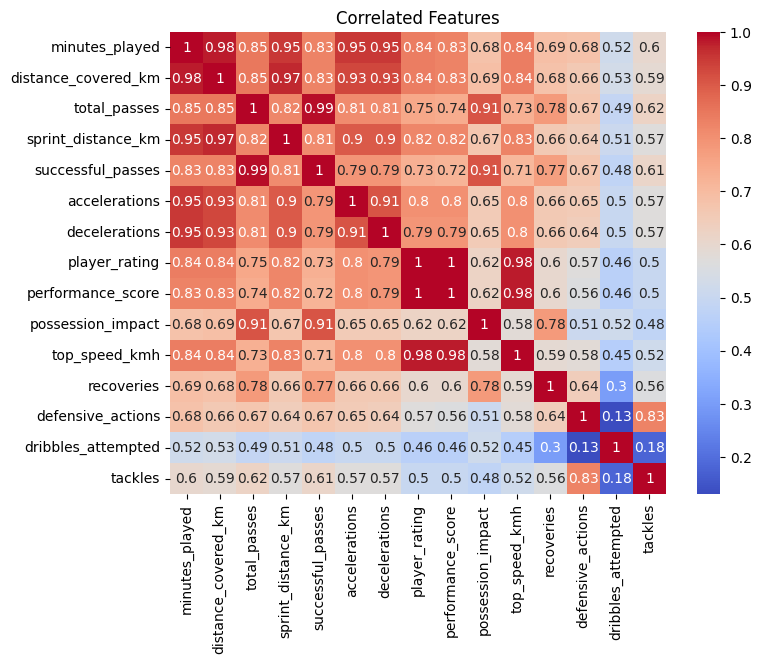


Correlation with player_rating
performance_score           0.996661
top_speed_kmh               0.979691
distance_covered_km         0.837534
minutes_played              0.837339
sprint_distance_km          0.821266
accelerations               0.799028
decelerations               0.794962
total_passes                0.745521
successful_passes           0.726532
possession_impact           0.623876
recoveries                  0.604887
defensive_actions           0.567453
stamina_score               0.557274
aerial_duels_won            0.535284
tackles                     0.503513
interceptions               0.466071
dribbles_attempted          0.462979
fouls_committed             0.448107
key_passes                  0.447832
clearances                  0.439657
crosses                     0.436741
aerial_duels_lost           0.428459
shots                       0.419941
fouls_suffered              0.419178
blocks                      0.340418
successful_dribbles         0.301617
total_

In [51]:
explore_df = DataExplorer(train_df)
explore_df.exploration()

## Data Cleaning

In [52]:
### removing zero minutes played rows
# print(train_df["minutes_played"].value_counts()) #there are 18524 of 0 minutes played rows
#remove zero minutes played rows since they contain no info- guess the model will get them if not but its easily hardcoded / predicted
train_df = train_df[train_df['minutes_played'] > 0].reset_index(drop=True) #


###dropping unrelated to performance cols
cols_to_drop = [
    'Id', 'player_name', 'match_id', 'match_date', 'stadium', 'city',
    'jersey_number', 'opponent_team', 'tournament_stage',
    'nationality', 'team', 'club_name','preferred_foot'
]
train_df = train_df.drop(columns= cols_to_drop)

print ("Positions are:")
print(train_df["position"].value_counts())

print ("Match results are")
print(train_df["match_result"].value_counts())

train_df = pd.get_dummies(train_df, columns=['position'], prefix='pos')
train_df = pd.get_dummies(train_df, columns=['match_result'], prefix='result')


train_df_cleaned = DataCleaner(train_df).clean_df()


Positions are:
position
Defender      9150
Midfielder    8147
Forward       6078
Goalkeeper    1685
Name: count, dtype: int64
Match results are
match_result
L    9230
W    9226
D    6604
Name: count, dtype: int64


### Exploring after cleaning 

-----------------
DataSet Shape is (24599, 67)
-----------------
-----------------


=== STATISTICS ===
                age     height_cm     weight_kg  market_value_eur  \
count  24599.000000  24599.000000  24599.000000      2.459900e+04   
mean      26.308915    181.232448     75.694256      1.864549e+07   
std        3.992073      6.192257      3.904240      2.159328e+07   
min       17.000000    163.000000     65.000000      5.288220e+05   
25%       24.000000    177.000000     73.000000      4.686013e+06   
50%       26.000000    182.000000     76.000000      1.027216e+07   
75%       29.000000    186.000000     78.000000      2.383264e+07   
99%       35.000000    194.000000     84.000000      9.845041e+07   
max       39.000000    200.000000     85.000000      1.184785e+08   

         goals_team  goals_opponent  minutes_played         goals  \
count  24599.000000    24599.000000    24599.000000  24599.000000   
mean       1.328875        1.328428       62.533396      0.093744  

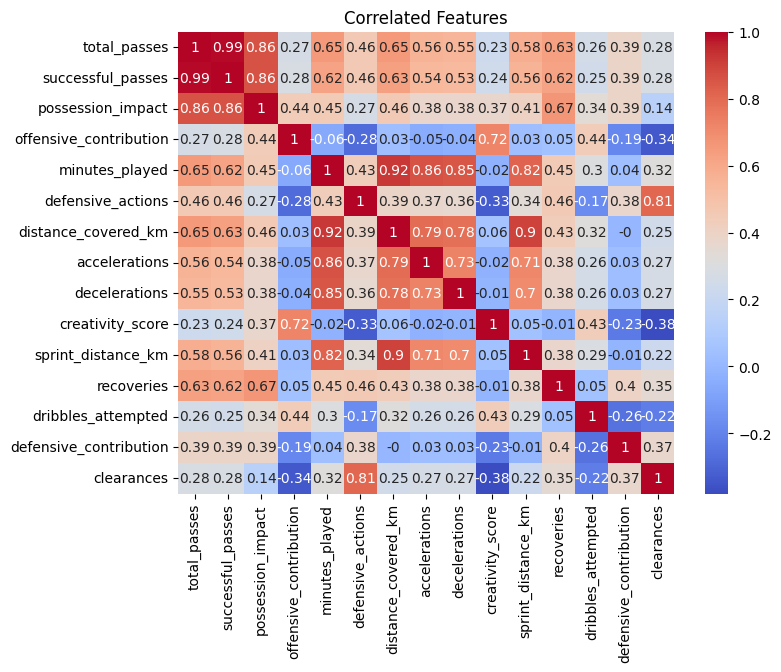


Correlation with player_rating
performance_score           0.925330
consistency_score           0.456260
pressure_resistance         0.430638
market_value_eur            0.415855
possession_impact           0.361315
offensive_contribution      0.323779
creativity_score            0.253318
total_passes                0.251130
successful_passes           0.242332
defensive_contribution      0.215281
goals                       0.176916
recoveries                  0.165847
dribbles_attempted          0.143322
key_passes                  0.139013
successful_dribbles         0.138970
assists                     0.133872
shots                       0.129221
player_of_match_awards      0.121619
stamina_score               0.112898
shots_on_target             0.106518
clutch_performance_score    0.086478
total_goals_tournament      0.077192
goals_team                  0.062024
expected_assists_xa         0.061942
total_assists_tournament    0.061045
expected_goals_xg           0.059335
goals_

In [53]:
cleaned_explorer = DataExplorer(train_df_cleaned).exploration()

### Feature Engineering

-----------------
DataSet Shape is (24599, 84)
-----------------
-----------------


=== STATISTICS ===
                age     height_cm     weight_kg  market_value_eur  \
count  24599.000000  24599.000000  24599.000000      2.459900e+04   
mean      26.308915    181.232448     75.694256      1.864549e+07   
std        3.992073      6.192257      3.904240      2.159328e+07   
min       17.000000    163.000000     65.000000      5.288220e+05   
25%       24.000000    177.000000     73.000000      4.686013e+06   
50%       26.000000    182.000000     76.000000      1.027216e+07   
75%       29.000000    186.000000     78.000000      2.383264e+07   
99%       35.000000    194.000000     84.000000      9.845041e+07   
max       39.000000    200.000000     85.000000      1.184785e+08   

         goals_team  goals_opponent  minutes_played         goals  \
count  24599.000000    24599.000000    24599.000000  24599.000000   
mean       1.328875        1.328428       62.533396      0.093744  

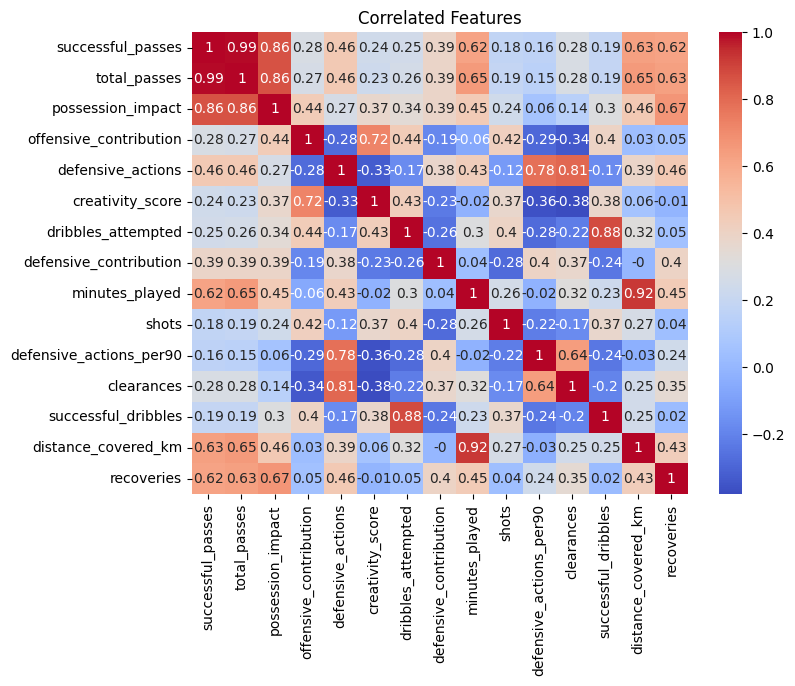


Correlation with player_rating
performance_score           0.925330
consistency_score           0.456260
pressure_resistance         0.430638
market_value_eur            0.415855
possession_impact           0.361315
offensive_contribution      0.323779
successful_passes_per90     0.310158
creativity_score            0.253318
total_passes                0.251130
successful_passes           0.242332
defensive_contribution      0.215281
goals                       0.176916
recoveries                  0.165847
recoveries_per90            0.160956
goals_overperformance       0.157972
goals_per90                 0.145825
dribbles_attempted          0.143322
key_passes                  0.139013
successful_dribbles         0.138970
assists                     0.133872
dribbles_attempted_per90    0.129683
shot_conversion             0.129224
shots                       0.129221
player_of_match_awards      0.121619
key_passes_per90            0.121274
dribble_success_rate        0.115553
shots_

In [54]:
#teams winning tend to have higher ratings
train_df_cleaned['goal_difference'] = (train_df_cleaned['goals_team'] - train_df_cleaned['goals_opponent'])

#i'm hoping that'll give a sense of the expected being the 'floor' of a player
train_df_cleaned['goals_overperformance'] = (train_df_cleaned['goals'] - train_df_cleaned['expected_goals_xg'])

train_df_cleaned['assist_overperformance'] = (train_df_cleaned['assists'] - train_df_cleaned['expected_assists_xa'])

#missing shots
train_df_cleaned['shot_conversion'] = np.where(train_df_cleaned['shots'] > 0,
    train_df_cleaned['goals'] / train_df_cleaned['shots']
    ,0
)

#Dribble success rate
train_df_cleaned['dribble_success_rate'] = np.where(
    train_df_cleaned['dribbles_attempted'] > 0,
    train_df_cleaned['successful_dribbles'] / train_df_cleaned['dribbles_attempted'],
    0
)

per_90_cols = [
    'goals', 'assists', 'shots', 'shots_on_target', 'key_passes',
    'tackles', 'interceptions', 'recoveries', 'defensive_actions',
    'successful_passes', 'dribbles_attempted'
]

for col in per_90_cols:
    train_df_cleaned[f'{col}_per90'] = np.where(
        train_df_cleaned['minutes_played'] > 0,
        train_df_cleaned[col] / train_df_cleaned['minutes_played'] * 90,
        0
    )


train_df_cleaned['bmi'] = train_df_cleaned['weight_kg'] / ((train_df_cleaned['height_cm']/100) ** 2)

 

cleaned_explorer = DataExplorer(train_df_cleaned).exploration() #okay all have good corelation with the result except for goals difference

## XAI Analysis

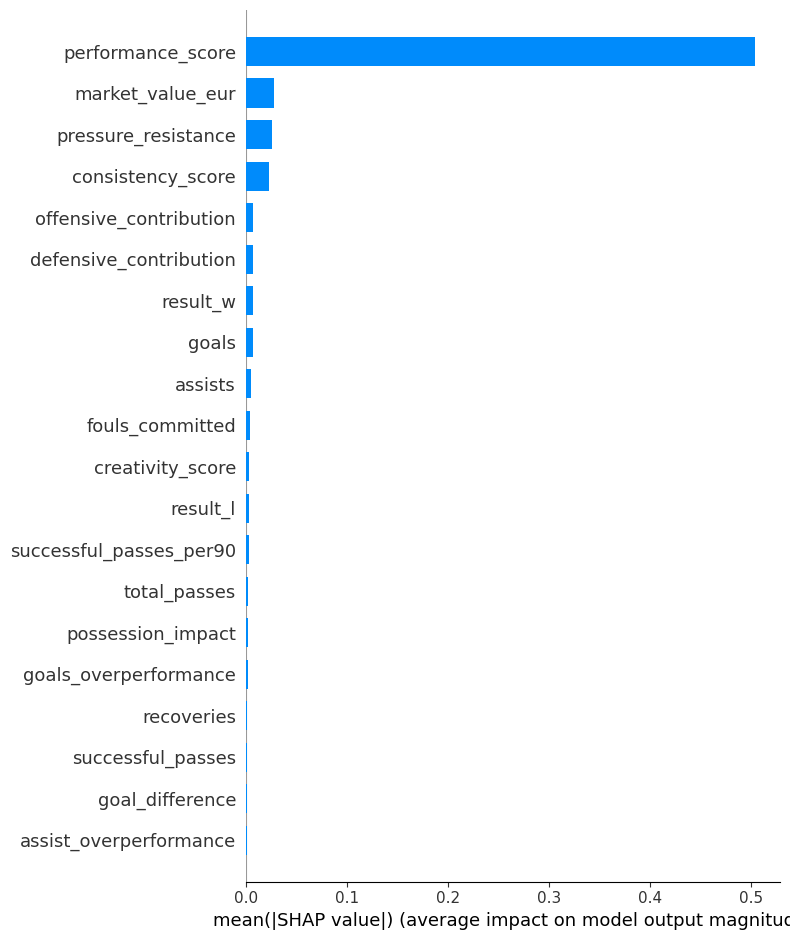

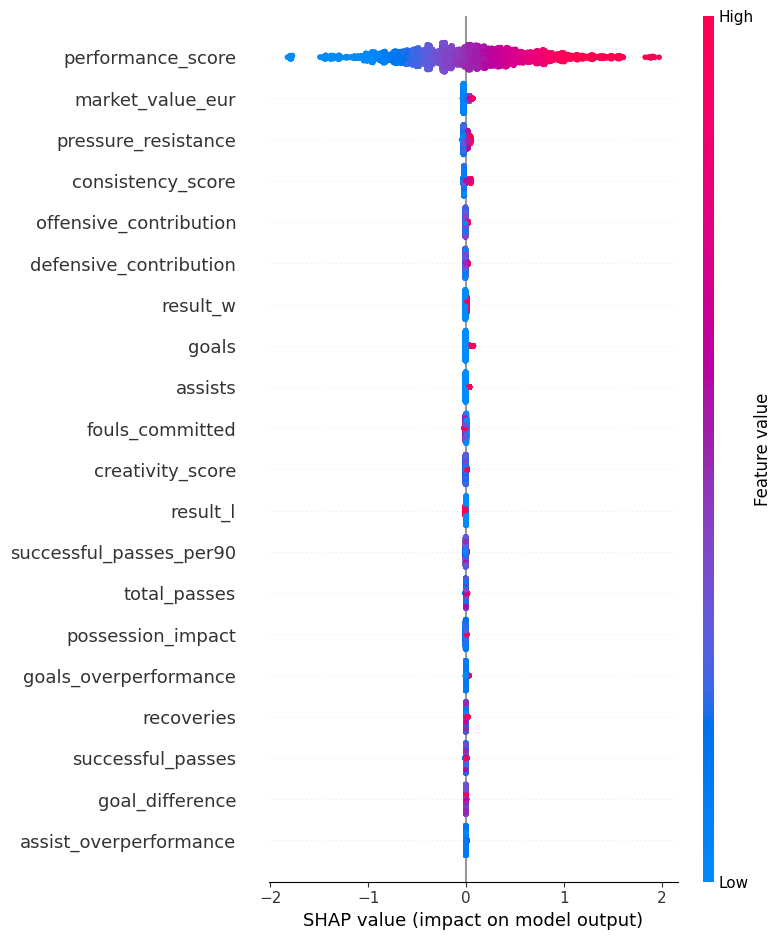

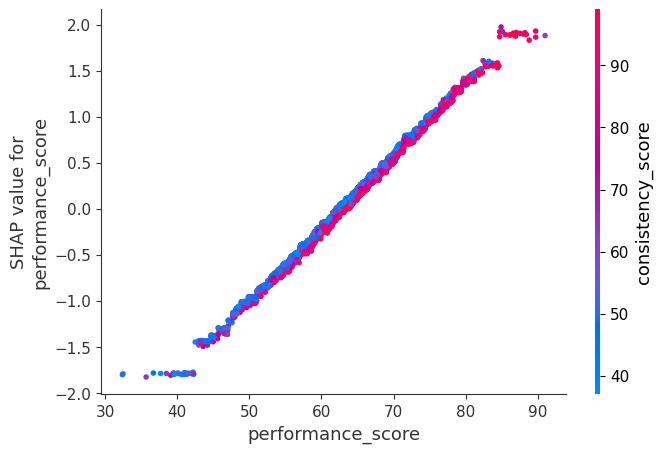

performance_score          0.503864
market_value_eur           0.027410
pressure_resistance        0.025678
consistency_score          0.023270
offensive_contribution     0.007252
defensive_contribution     0.007238
result_w                   0.007131
goals                      0.006715
assists                    0.004889
fouls_committed            0.003706
creativity_score           0.003229
result_l                   0.003122
successful_passes_per90    0.002791
total_passes               0.002311
possession_impact          0.002300
dtype: float64

performance_score share of total SHAP magnitude: 77.0%


In [55]:
import shap

# --- define X, y, groups directly from train_df_cleaned ---
target = 'player_rating'
ID = ['player_id']

X = train_df_cleaned.drop(columns=[target] + ID)
y = train_df_cleaned[target]
groups = train_df_cleaned['player_id']

# --- best params from Optuna wide search ---
best_params = {
    'depth': 6,
    'learning_rate': 0.010007132386538472,
    'l2_leaf_reg': 1.3630467109604305,
    'min_data_in_leaf': 32,
    'random_strength': 1.699987960279682,
    'bagging_temperature': 0.8333129955129245,
    'border_count': 254
}

model = CatBoostRegressor(
    iterations=5000,
    task_type='GPU',
    random_seed=42,
    verbose=False,
    early_stopping_rounds=50,
    **best_params
)

# clean single train/val split for SHAP (grouped, to respect player_id leakage rules)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X, y, groups=groups))
X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

model.fit(X_train, y_train, eval_set=(X_val, y_val))

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val)

# global feature importance
shap.summary_plot(shap_values, X_val, plot_type='bar', max_display=20)

# beeswarm — direction of effect per feature
shap.summary_plot(shap_values, X_val, max_display=20)

shap.dependence_plot('performance_score', shap_values, X_val)

# quantify performance_score's share of total explanatory power
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=X_val.columns).sort_values(ascending=False)
print(shap_importance.head(15))
print(f"\nperformance_score share of total SHAP magnitude: {shap_importance['performance_score'] / shap_importance.sum() * 100:.1f}%")

## Preparing Test set

In [56]:
# test_df = test_df.drop(columns= cols_to_drop)
# test_df = pd.get_dummies(test_df, columns=['position'], prefix='pos')
# test_df = pd.get_dummies(test_df, columns=['match_result'], prefix='result')

# test_df_cleaned = DataCleaner(test_df).clean_df()

# test_df_cleaned['goal_difference'] = (test_df_cleaned['goals_team'] - test_df_cleaned['goals_opponent'])
# test_df_cleaned['goals_overperformance'] = (test_df_cleaned['goals'] - test_df_cleaned['expected_goals_xg'])
# test_df_cleaned['assist_overperformance'] = (test_df_cleaned['assists'] - test_df_cleaned['expected_assists_xa'])
# test_df_cleaned['shot_conversion'] = np.where(test_df_cleaned['shots'] > 0,
#     test_df_cleaned['goals'] / test_df_cleaned['shots'], 0)
# test_df_cleaned['dribble_success_rate'] = np.where(
#     test_df_cleaned['dribbles_attempted'] > 0,
#     test_df_cleaned['successful_dribbles'] / test_df_cleaned['dribbles_attempted'], 0)


# Models testing

## lightgbm

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error

# Separate features/target/groups
target = 'player_rating'
ID = ['id']  

X = train_df_cleaned.drop(columns=[target] + ID)
y = train_df_cleaned[target]
groups = train_df_cleaned['player_id']

gkf = GroupKFold(n_splits=5)

fold_scores = []
models = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMRegressor(n_estimators= 2000, learning_rate= 0.03 , num_leaves= 31,
                            max_depth= -1 , min_child_samples= 20, subsample=0.8 , colsample_bytree= 0.8 , reg_alpha= 0.1,
                            reg_lambda= 0.1, random_state= 42
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    fold_scores.append(mse)
    models.append(model)

print(f"\nMean CV MSE: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

fold_scores_rf = []
for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = RandomForestRegressor(
        n_estimators=500, max_depth = 12 , min_samples_leaf = 5 , max_features='sqrt',
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    fold_scores_rf.append(mse)

print(f"\nMean CV MSE {np.mean(fold_scores_rf):.4f} (+/- {np.std(fold_scores_rf):.4f})")

## XGBoost

In [ ]:
import xgboost as xgb

fold_scores_xgb = []
for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = xgb.XGBRegressor(
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=6,                 # XGB default-ish, controls tree complexity directly (unlike LightGBM's leaf-wise growth)
        min_child_weight=5,          # analogous to min_child_samples — guards rare-event overfitting
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,               # XGB default L2 is already meaningful, keep it higher than alpha
        random_state=42,
        early_stopping_rounds=50,
        eval_metric='rmse'
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    fold_scores_xgb.append(mse)

print(f"\nMean CV MSE : {np.mean(fold_scores_xgb):.4f} (+/- {np.std(fold_scores_xgb):.4f})")

In [ ]:
from catboost import CatBoostRegressor

fold_scores_cb = []
for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=2000, depth=6, l2_leaf_reg=3,random_seed=42,
        learning_rate=0.03,
        early_stopping_rounds=50,
        verbose=False
    )
    model.fit(X_train, y_train, eval_set=(X_val, y_val))

    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    fold_scores_cb.append(mse)

print(f"\nMean CV MSE {np.mean(fold_scores_cb):.4f} (+/- {np.std(fold_scores_cb):.4f})")

## Hyperparameter search

In [ ]:
gkf = GroupKFold(n_splits=5)

param_grid = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.07],
    'l2_leaf_reg': [1, 3, 5, 7, 10],
    'min_data_in_leaf': [1, 5, 10, 20],
    'random_strength': [0.5, 1, 3, 5],
    'bagging_temperature': [0, 0.5, 1],
    'border_count': [128, 254],
}

keys = list(param_grid.keys())
combinations = list(itertools.product(*param_grid.values()))
total_combos = len(combinations)

results_path = 'catboost_grid_search_results.csv'

# ANSI colors for highlighting new bests
GREEN = '\033[92m'
BOLD = '\033[1m'
RESET = '\033[0m'

# resume support: skip combos already done if the file exists
completed_params = set()
best_mse = float('inf')
best_params = None

if os.path.exists(results_path):
    existing = pd.read_csv(results_path)
    for _, row in existing.iterrows():
        key_tuple = tuple(row[k] for k in keys)
        completed_params.add(key_tuple)
    if len(existing) > 0:
        best_row = existing.loc[existing['mean_mse'].idxmin()]
        best_mse = best_row['mean_mse']
        best_params = {k: best_row[k] for k in keys}
    print(f"Found existing results file with {len(existing)} completed combos — resuming.")
    print(f"Current best MSE so far: {best_mse:.4f}")
else:
    # write header once
    pd.DataFrame(columns=keys + ['mean_mse', 'std_mse']).to_csv(results_path, index=False)

start_time = time.time()

for i, combo in enumerate(combinations):
    if combo in completed_params:
        continue  # already done, skip (supports resuming after interruption)

    params = dict(zip(keys, combo))

    fold_mses = []
    for train_idx, val_idx in gkf.split(X, y, groups=groups):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = CatBoostRegressor(
            iterations=5000,
            task_type='GPU',
            devices='0',
            random_seed=42,
            verbose=False,
            early_stopping_rounds=50,
            **params
        )
        model.fit(X_train, y_train, eval_set=(X_val, y_val))

        preds = model.predict(X_val)
        fold_mses.append(mean_squared_error(y_val, preds))

    mean_mse = np.mean(fold_mses)
    std_mse = np.std(fold_mses)

    # append this single row to the CSV immediately
    row_df = pd.DataFrame([{**params, 'mean_mse': mean_mse, 'std_mse': std_mse}])
    row_df.to_csv(results_path, mode='a', header=False, index=False)

    elapsed = time.time() - start_time

    is_new_best = mean_mse < best_mse
    if is_new_best:
        best_mse = mean_mse
        best_params = params

    line = (f"[{i+1}/{total_combos}] MSE={mean_mse:.4f} | "
            f"best_so_far={best_mse:.4f} | elapsed={elapsed/60:.1f}min")

    if is_new_best:
        print(f"{GREEN}{BOLD}{line}  <-- NEW BEST{RESET}")
    else:
        print(line)

print("\nDone. Loading final results...")
results_df = pd.read_csv(results_path).sort_values('mean_mse')
results_df['rmse'] = np.sqrt(results_df['mean_mse'])
results_df = results_df.sort_values('mean_mse')  # still rank by MSE, matches competition scoring
print(results_df[['depth', 'learning_rate', 'l2_leaf_reg', 'min_data_in_leaf',
                   'random_strength', 'bagging_temperature', 'border_count',
                   'mean_mse', 'rmse', 'std_mse']].head(10))

print(results_df.iloc[0])